In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from joblib import dump,load

In [71]:
df=pd.read_csv("gym_members_exercise_tracking.csv")
print(df.head())

   Age  Gender  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  \
0   56    Male         88.3        1.71      180      157           60   
1   46  Female         74.9        1.53      179      151           66   
2   32  Female         68.1        1.66      167      122           54   
3   25    Male         53.2        1.70      190      164           56   
4   38    Male         46.1        1.79      188      158           68   

   Session_Duration (hours)  Calories_Burned Workout_Type  Fat_Percentage  \
0                      1.69           1313.0         Yoga            12.6   
1                      1.30            883.0         HIIT            33.9   
2                      1.11            677.0       Cardio            33.4   
3                      0.59            532.0     Strength            28.8   
4                      0.64            556.0     Strength            29.2   

   Water_Intake (liters)  Workout_Frequency (days/week)  Experience_Level  \
0              

In [72]:
print("outlier check")
df.describe()

outlier check


,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

In [74]:
print("\nMisssing Values:")
print(df.isnull().sum())


Misssing Values:
Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64


In [75]:
corr = df.corr(numeric_only=True)

print(corr['Calories_Burned'].sort_values(ascending=False))

Calories_Burned                  1.000000
Session_Duration (hours)         0.908140
Experience_Level                 0.694129
Workout_Frequency (days/week)    0.576150
Water_Intake (liters)            0.356931
Avg_BPM                          0.339659
Weight (kg)                      0.095443
Height (m)                       0.086348
BMI                              0.059761
Resting_BPM                      0.016518
Max_BPM                          0.002090
Age                             -0.154679
Fat_Percentage                  -0.597615
Name: Calories_Burned, dtype: float64


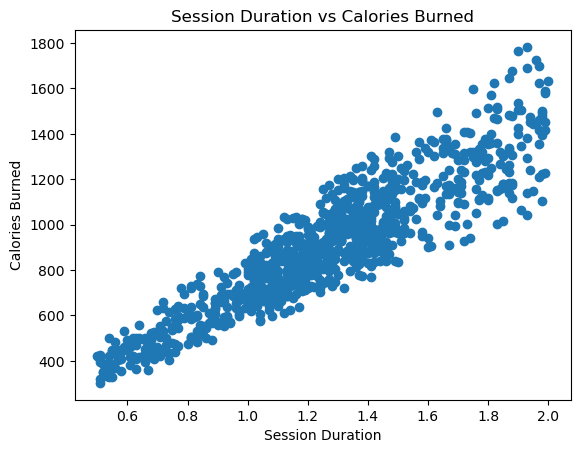

In [76]:
plt.scatter(df['Session_Duration (hours)'], df['Calories_Burned'])
plt.xlabel('Session Duration')
plt.ylabel('Calories Burned')
plt.title('Session Duration vs Calories Burned')
plt.show()

In [77]:
df_encoded=pd.get_dummies(df,columns=['Gender','Workout_Type'],drop_first=True)
print("\nEncoded Dataset:")
print(df_encoded.head())



Encoded Dataset:
   Age  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  \
0   56         88.3        1.71      180      157           60   
1   46         74.9        1.53      179      151           66   
2   32         68.1        1.66      167      122           54   
3   25         53.2        1.70      190      164           56   
4   38         46.1        1.79      188      158           68   

   Session_Duration (hours)  Calories_Burned  Fat_Percentage  \
0                      1.69           1313.0            12.6   
1                      1.30            883.0            33.9   
2                      1.11            677.0            33.4   
3                      0.59            532.0            28.8   
4                      0.64            556.0            29.2   

   Water_Intake (liters)  Workout_Frequency (days/week)  Experience_Level  \
0                    3.5                              4                 3   
1                    2.1                      

In [78]:
X=df_encoded.drop('Calories_Burned',axis=1)
y=df['Calories_Burned']

In [79]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [80]:
y_pred=model.predict(X_test)

In [81]:
print("R2 Score:",r2_score(y_test,y_pred))
print("\nMAE:",mean_absolute_error(y_test,y_pred))
print("\nMSE:",mean_squared_error(y_test,y_pred))

R2 Score: 0.9802675995368528

MAE: 30.27013984532079

MSE: 1646.17601459704


In [82]:
result=pd.DataFrame({
    'Actual Calories':y_test,
    'Predicted Calories':y_pred
})
print("\nSample Predictions:")
print(result.head(10))


Sample Predictions:
     Actual Calories  Predicted Calories
199            929.0          913.292902
538           1401.0         1416.980086
174            925.0          956.023330
464           1155.0         1109.334421
66            1587.0         1504.428161
424           1247.0         1303.889503
718            950.0          961.044150
346            927.0          938.783883
281           1053.0         1039.390921
158           1201.0         1195.974336


In [83]:
dump(model,"Calorie model.joblib")
loaded_model=load("Calorie model.joblib")